# Fine-Tuning Nemotron Parse v1.1 on Invoices

**A step-by-step tutorial for adapting NVIDIA's document-parsing model
to extract structured invoice data using [NeMo Automodel](https://github.com/NVIDIA-NeMo/Automodel).**

---

## What is Nemotron Parse?

[Nemotron Parse v1.1](https://huggingface.co/nvidia/NVIDIA-Nemotron-Parse-v1.1)
is an encoder-decoder vision-language model for document understanding.
Given a scanned page, it outputs structured text.

| Component | Role | Params | Trainable? |
|-----------|------|--------|------------|
| **RADIO vision encoder** | Converts an image into visual tokens | ~600 M | Frozen |
| **Neck (conv + projection)** | Maps visual tokens to decoder dim | ~5 M | Frozen |
| **mBART text decoder** | Autoregressively produces structured text | ~300 M | **Yes** |

## The Task

We fine-tune Nemotron Parse to extract structured fields from **invoices**:

| Field | Example |
|-------|---------|
| `invoice_no` | 40378170 |
| `invoice_date` | 10/15/2012 |
| `seller` | Patel, Thompson and Montgomery... |
| `client` | Jackson, Odonnell and Jackson... |
| `items` | line items with description, qty, price, VAT |
| `summary` | total net, total VAT, total gross |

The **base model** produces generic markdown from invoice images.
After fine-tuning, it outputs **exactly the structured fields** we need.

## Tutorial Overview

| Step | Description |
|------|-------------|
| **Step 0** | Environment setup (Docker container, dependencies) |
| **Step 1** | Explore the invoice dataset |
| **Step 2** | Evaluate the base model (before fine-tuning) |
| **Step 3** | Prepare data and training configuration |
| **Step 4** | Launch fine-tuning with NeMo Automodel |
| **Step 5** | Evaluate the fine-tuned model |
| **Step 6** | Compare results (NED scores, field-level accuracy) |

## Hardware Requirements

This notebook has been tested on **4× A100 80 GB** GPUs. It can also be run on a **single A100** by adjusting `--nproc_per_node` and batch size parameters.

**Estimated training time**: ~30 min on 4× A100 (425 samples, 10 epochs).


## Step 0 — Environment Setup

This notebook runs **inside** the NeMo Automodel Docker container:

```bash
docker run -it --rm --gpus all --ipc=host --network host \
    -p 8888:8888 -v $(pwd):/workspace \
    nvcr.io/nvidia/nemo-automodel:26.02

# Inside the container:
huggingface-cli login
pip install jupyterlab
jupyter lab --ip=0.0.0.0 --port=8888 --allow-root --no-browser
```

Then open this notebook at `http://<host>:8888`.


In [ ]:
# Step 0: Environment setup (idempotent)

import gc
import glob
import json
import logging
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import transformers
from datasets import load_dataset

print(f"\nPyTorch      : {torch.__version__}")
print(f"Transformers : {transformers.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    mem = getattr(props, "total_memory", None) or getattr(props, "total_mem", 0)
    print(f"GPU Memory   : {mem / 1024**3:.1f} GB")
print("\nSetup complete.")

---

## Step 1 — Explore the Invoice Dataset

We use [`katanaml-org/invoices-donut-data-v1`](https://huggingface.co/datasets/katanaml-org/invoices-donut-data-v1)
— a dataset of **425 synthetic invoices** with structured ground-truth labels.

Each sample contains:
- **`image`**: A scanned invoice (PIL Image)
- **`ground_truth`**: JSON with `gt_parse` containing `header`, `items`, `summary`


In [12]:
dataset = load_dataset("katanaml-org/invoices-donut-data-v1")

print(f"Train      : {len(dataset['train'])} samples")
print(f"Validation : {len(dataset['validation'])} samples")
print(f"Test       : {len(dataset['test'])} samples")

ex = dataset["train"][0]
gt = json.loads(ex["ground_truth"])["gt_parse"]
print(f"\nGround-truth keys: {list(gt.keys())}")
print("\nHeader fields:")
for k, v in gt["header"].items():
    print(f"  {k:20s}: {v}")
print(f"\nLine items ({len(gt['items'])}):")
for item in gt["items"][:3]:
    print(f"  {item}")
print("\nSummary:")
for k, v in gt["summary"].items():
    print(f"  {k:20s}: {v}")

Train      : 425 samples
Validation : 50 samples
Test       : 26 samples

Ground-truth keys: ['header', 'items', 'summary']

Header fields:
  invoice_no          : 40378170
  invoice_date        : 10/15/2012
  seller              : Patel, Thompson and Montgomery 356 Kyle Vista New James, MA 46228
  client              : Jackson, Odonnell and Jackson 267 John Track Suite 841 Jenniferville, PA 98601
  seller_tax_id       : 958-74-3511
  client_tax_id       : 998-87-7723
  iban                : GB77WRBQ31965128414006

Line items (1):
  {'item_desc': "Leed's Wine Companion Bottle Corkscrew Opener Gift Box Set with Foil Cutter", 'item_qty': '1,00', 'item_net_price': '7,50', 'item_net_worth': '7,50', 'item_vat': '10%', 'item_gross_worth': '8,25'}

Summary:
  total_net_worth     : $7,50
  total_vat           : $0,75
  total_gross_worth   : $8,25


Let's visualize a few **training** invoices alongside their ground-truth header fields to get a feel for the data.

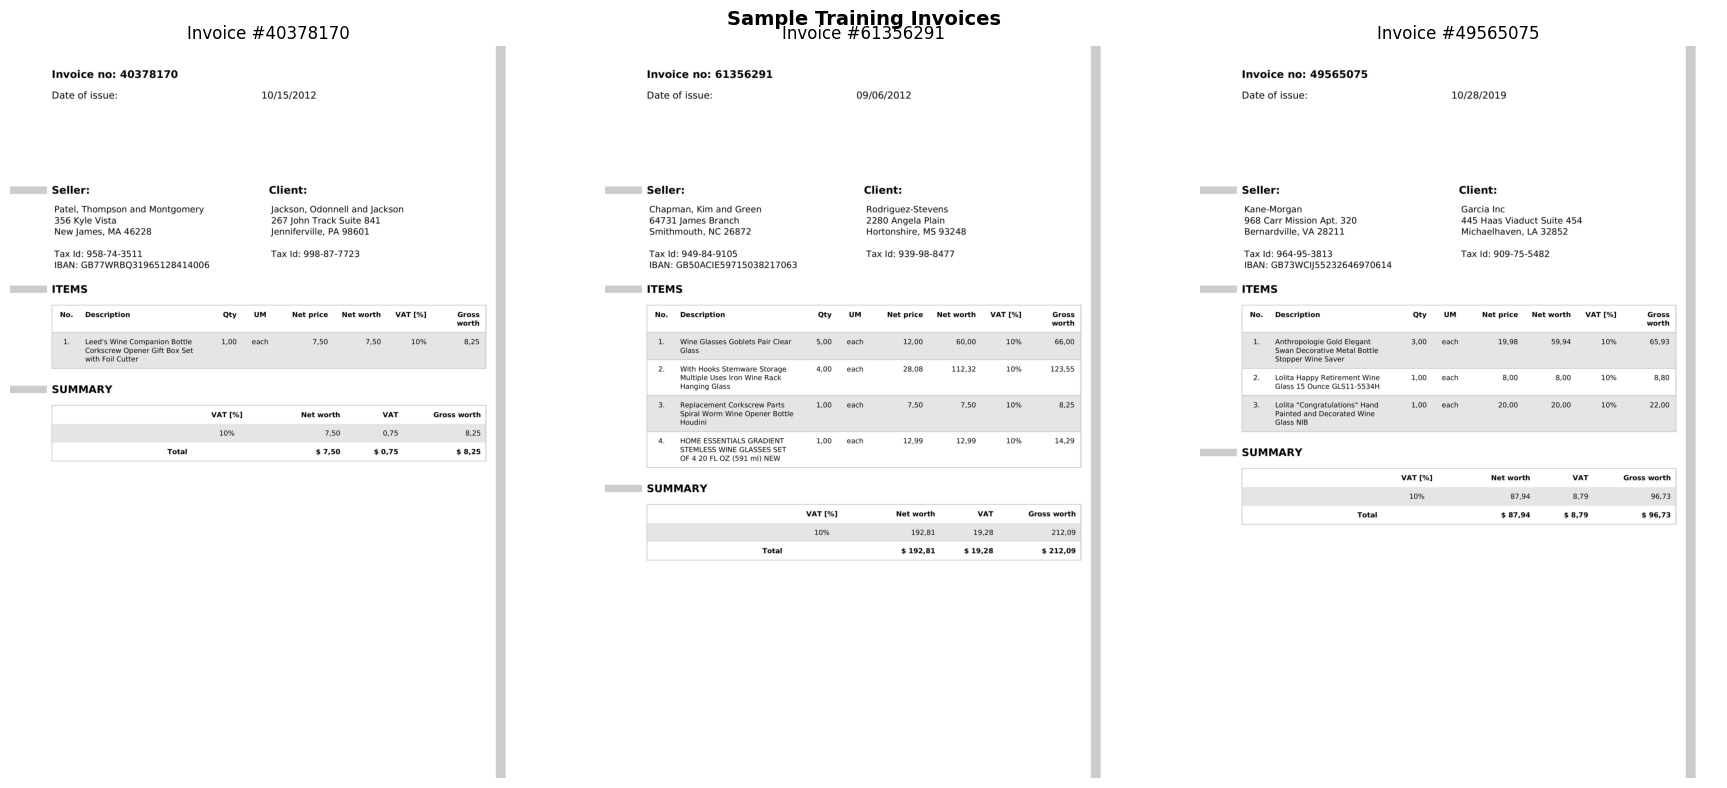

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for i, ax in enumerate(axes):
    ex = dataset["train"][i]
    gt = json.loads(ex["ground_truth"])["gt_parse"]
    ax.imshow(ex["image"])
    ax.set_title(f"Invoice #{gt['header'].get('invoice_no', '?')}", fontsize=12)
    ax.axis("off")
plt.suptitle("Sample Training Invoices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Below is a sample of the **test** set — these invoices are held out and used only for evaluation.

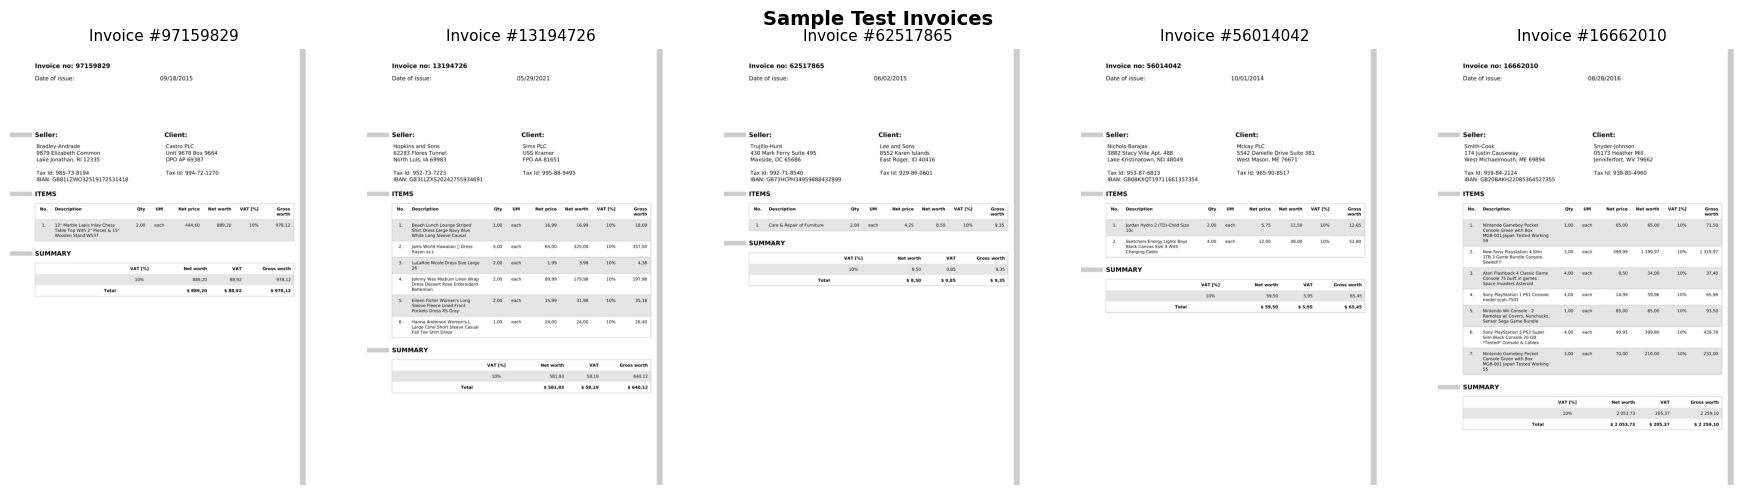

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, ax in enumerate(axes):
    ex = dataset["test"][i]
    gt = json.loads(ex["ground_truth"])["gt_parse"]
    ax.imshow(ex["image"])
    ax.set_title(f"Invoice #{gt['header'].get('invoice_no', '?')}", fontsize=11)
    ax.axis("off")
plt.suptitle("Sample Test Invoices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Step 2 — Evaluate the Base Model (Before Fine-Tuning)

The pretrained model outputs generic markdown — it can read invoice text but
does not know our target structure (`header` / `items` / `summary`).

| NED Score | Meaning |
|-----------|---------|
| 0.0 | Perfect match |
| < 0.05 | Near-perfect (minor character differences) |
| 0.3–0.5 | Close but some errors |
| 0.8–1.0 | Very different (wrong format) |


We define helper functions used throughout the notebook:

- **`json2token`** — imported from the co-located `invoice_dataset.py`. Converts a structured JSON ground-truth dict into the XML-like token sequence the model is trained to produce (e.g., `<s_invoice_no>40378170</s_invoice_no>`).
- **`compute_ned`** — computes Normalized Edit Distance between two strings (0 = identical, 1 = completely different).
- **`run_inference`** — runs a single image through the model: processes the image, constructs the decoder prompt, generates tokens, and decodes the result.
- **`evaluate_invoices`** — runs `run_inference` on multiple test samples and reports per-sample NED.
- **`extract_field` / `compute_field_accuracy`** — parses structured `<s_field>...</s_field>` tags from the prediction and computes exact-match accuracy per field.

In [ ]:
# Evaluation helpers

from transformers import AutoProcessor

from nemo_automodel import NeMoAutoModelForImageTextToText

from invoice_dataset import json2token


def compute_ned(pred: str, target: str) -> float:
    m, n = len(pred), len(target)
    if max(m, n) == 0:
        return 0.0

    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, n + 1):
            tmp = dp[j]
            dp[j] = prev if pred[i - 1] == target[j - 1] else 1 + min(dp[j], dp[j - 1], prev)
            prev = tmp
    return dp[n] / max(m, n)


def run_inference(model, processor, pil_image, task_prompt=None, max_new_tokens=4400, num_beams=1):
    if task_prompt is None:
        task_prompt = "</s><s>"
    tokenizer = processor.tokenizer

    decoder_start_token_id = getattr(model.config, "decoder_start_token_id", 2)
    prompt_tokens = tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt")["input_ids"]
    start_token = torch.tensor([[decoder_start_token_id]], dtype=torch.long)
    decoder_start_ids = torch.cat([start_token, prompt_tokens], dim=1).to("cuda")

    image = pil_image.convert("RGB") if pil_image.mode != "RGB" else pil_image
    image_inputs = processor.image_processor(image, return_tensors="pt")
    pixel_values = image_inputs["pixel_values"].to(device="cuda", dtype=torch.bfloat16)

    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values=pixel_values,
            decoder_input_ids=decoder_start_ids,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            use_cache=False,
        )

    prompt_len = decoder_start_ids.shape[1]
    gen_tokens = generated_ids[0, prompt_len:]
    return tokenizer.decode(gen_tokens, skip_special_tokens=True)


def evaluate_invoices(model, processor, test_dataset, n_samples=20, task_prompt=None, num_beams=1):
    model.eval()
    results = []
    n = min(n_samples, len(test_dataset))
    for i in range(n):
        ex = test_dataset[i]
        gt = json.loads(ex["ground_truth"])["gt_parse"]
        target = json2token(gt)
        pred = run_inference(model, processor, ex["image"], task_prompt=task_prompt, num_beams=num_beams)
        ned = compute_ned(pred, target)
        results.append({"idx": i, "ned": ned, "pred": pred, "target": target, "gt": gt})
        print(f"  Sample {i:2d}: NED = {ned:.4f}")
    avg_ned = sum(r["ned"] for r in results) / len(results)
    print(f"\n  Average NED: {avg_ned:.4f}")
    return avg_ned, results


def extract_field(pred_text, field_name):
    """Extract a field value from structured <s_field>value</s_field> tags."""
    pattern = rf"<s_{re.escape(field_name)}>(.*?)</s_{re.escape(field_name)}>"
    match = re.search(pattern, pred_text, re.DOTALL)
    return match.group(1).strip() if match else None


def compute_field_accuracy(results):
    header_fields = ["invoice_no", "invoice_date", "seller", "client", "seller_tax_id", "client_tax_id", "iban"]
    field_correct = {f: 0 for f in header_fields}
    field_total = {f: 0 for f in header_fields}
    for r in results:
        gt_header = r["gt"].get("header", {})
        pred_text = r["pred"]
        for field in header_fields:
            gt_val = gt_header.get(field, "")
            if gt_val:
                field_total[field] += 1
                extracted = extract_field(pred_text, field)
                if extracted and extracted == gt_val:
                    field_correct[field] += 1
    print("\n  Field-level accuracy (structured tag extraction, exact match):")
    print(f"  {'Field':20s}  {'Correct':>7s} / {'Total':>5s}  {'Accuracy':>8s}")
    print(f"  {'-' * 50}")
    for f in header_fields:
        tot = field_total[f]
        cor = field_correct[f]
        acc = cor / tot * 100 if tot > 0 else 0
        print(f"  {f:20s}  {cor:7d} / {tot:5d}  {acc:7.1f}%")
    overall = sum(field_correct.values()) / max(sum(field_total.values()), 1) * 100
    print(f"  {'OVERALL':20s}  {sum(field_correct.values()):7d} / {sum(field_total.values()):5d}  {overall:7.1f}%")
    return field_correct, field_total


NUM_EVAL = 20
print(f"Eval helpers loaded. Will evaluate on {NUM_EVAL} test samples.")

Load the base (pretrained) Nemotron Parse v1.1 model using `NeMoAutoModelForImageTextToText` and evaluate it on the test set. The task prompt `</s><s><predict_bbox><predict_classes><output_markdown>` tells the model to engage its vision pipeline and produce structured output.

In [ ]:
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("httpx").setLevel(logging.ERROR)

HF_TOKEN = os.environ.get("HF_TOKEN", None)

print("Loading base Nemotron Parse v1.1 ...")
processor = AutoProcessor.from_pretrained(
    "nvidia/NVIDIA-Nemotron-Parse-v1.1",
    trust_remote_code=True,
    token=HF_TOKEN,
)
base_model = NeMoAutoModelForImageTextToText.from_pretrained(
    "nvidia/NVIDIA-Nemotron-Parse-v1.1",
    torch_dtype=torch.bfloat16,
    use_liger_kernel=False,
    attn_implementation="eager",
    trust_remote_code=True,
    token=HF_TOKEN,
).eval()
print(
    f"Base model loaded on {next(base_model.parameters()).device}.  Parameters: {sum(p.numel() for p in base_model.parameters()):,}\n"
)

BASE_TASK_PROMPT = "</s><s><predict_bbox><predict_classes><output_markdown>"

print("Evaluating base model on invoice test set:")
base_avg_ned, base_results = evaluate_invoices(
    base_model,
    processor,
    dataset["test"],
    n_samples=NUM_EVAL,
    task_prompt=BASE_TASK_PROMPT,
)
print("\nBase model field accuracy:")
base_fc, base_ft = compute_field_accuracy(base_results)

Free GPU memory before fine-tuning — the base model is no longer needed.

In [ ]:
for _var in ["base_model"]:
    if _var in globals():
        del globals()[_var]
torch.cuda.empty_cache()
gc.collect()
print("GPU memory freed.")

GPU memory freed.


---

## Step 3 — Prepare Data for Fine-Tuning

### Target format

Nemotron Parse expects training targets as an XML-like **token sequence**.
Each JSON key becomes a tag pair, and list items are separated by `<sep/>`.

The `json2token()` function converts the `gt_parse` dict automatically:

```
<s_header><s_client>...</s_client><s_invoice_date>10/15/2012</s_invoice_date>...</s_header>
<s_items><s_item_desc>...</s_item_desc><s_item_qty>1,00</s_item_qty>...<sep/>...</s_items>
<s_summary><s_total_gross_worth>10,06</s_total_gross_worth>...</s_summary>
```


In [ ]:
ex = dataset["train"][0]
gt = json.loads(ex["ground_truth"])["gt_parse"]
token_seq = json2token(gt)

print("Ground truth (structured):")
print(f"  Header fields: {list(gt['header'].keys())}")
print(f"  Num items    : {len(gt['items'])}")
print(f"  Summary keys : {list(gt['summary'].keys())}")
print("\nToken sequence (first 500 chars):")
print(f"  {token_seq[:500]}...")
print(f"\nTotal length: {len(token_seq)} characters")

Ground truth (structured):
  Header fields: ['invoice_no', 'invoice_date', 'seller', 'client', 'seller_tax_id', 'client_tax_id', 'iban']
  Num items    : 1
  Summary keys : ['total_net_worth', 'total_vat', 'total_gross_worth']

Token sequence (first 500 chars):
  <s_header><s_client>Jackson, Odonnell and Jackson 267 John Track Suite 841 Jenniferville, PA 98601</s_client><s_client_tax_id>998-87-7723</s_client_tax_id><s_iban>GB77WRBQ31965128414006</s_iban><s_invoice_date>10/15/2012</s_invoice_date><s_invoice_no>40378170</s_invoice_no><s_seller>Patel, Thompson and Montgomery 356 Kyle Vista New James, MA 46228</s_seller><s_seller_tax_id>958-74-3511</s_seller_tax_id></s_header><s_items><s_item_desc>Leed's Wine Companion Bottle Corkscrew Opener Gift Box Set wi...

Total length: 869 characters


### Training Configuration (YAML)

| Parameter | Value | Description |
|-----------|-------|-------------|
| `global_batch_size` | 8 | Effective batch size across all GPUs |
| `local_batch_size` | 2 | Per-GPU micro-batch size |
| `max_steps` | 530 | Total training steps (~10 epochs) |
| `val_every_steps` | 100 | Validation frequency |
| `lr` | 2e-5 | Learning rate |
| `freeze_vision_tower` | true | Keep RADIO encoder frozen |
| `freeze_language_model` | false | **Train the mBART decoder** |


We prepare two files that the training script needs:

1. **`invoice_dataset.py`** — co-located with this notebook, it contains `json2token` and `make_invoice_dataset`. We copy it to `/workspace/` so `torchrun` can find it at runtime.
2. **`invoice_nemotron_parse.yaml`** — the YAML config that controls all training hyperparameters (batch size, learning rate, epochs, checkpoint frequency, etc.).

---

## Step 4 — Launch Fine-Tuning

Training uses `torchrun` for distributed training. Adjust `--nproc_per_node`
to match your GPU count.

**What to watch:**
- `loss` should decrease from ~5+ to < 1.0
- `val_loss` should also decrease
- Training takes ~30 min on 4x A100


In [ ]:
!torchrun --nproc_per_node=auto Automodel/examples/vlm_finetune/finetune.py \
    --config nemotron_parse_config.yaml 2>&1 | tee train_log.txt; echo "EXIT CODE: $?"

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
W0326 22:30:36.815000 15446 torch/distributed/run.py:811] 
W0326 22:30:36.815000 15446 torch/distributed/run.py:811] *****************************************
W0326 22:30:36.815000 15446 torch/distributed/run.py:811] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0326 22:30:36.815000 15446 torch/distributed/run.py:811] *****************************************
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If 

---

## Step 5 — Evaluate the Fine-Tuned Model

We load the latest checkpoint and run the same evaluation.
The fine-tuned model should output structured invoice fields instead of
generic markdown, significantly lowering NED and improving field accuracy.


In [ ]:
WORK_DIR = str(Path.home())
ckpt_dirs = sorted(glob.glob(f"{WORK_DIR}/nemotron_parse_checkpoints/epoch_*_step_*"))
assert ckpt_dirs, f"No checkpoints found in {WORK_DIR}/nemotron_parse_checkpoints/"
latest = ckpt_dirs[-1]
consolidated = os.path.join(latest, "model", "consolidated")
assert os.path.isdir(consolidated), f"Consolidated checkpoint not found at {consolidated}"
print(f"Using checkpoint: {latest}")

print("Loading fine-tuned model ...")
ft_processor = AutoProcessor.from_pretrained(consolidated, trust_remote_code=True)
ft_model = NeMoAutoModelForImageTextToText.from_pretrained(
    consolidated,
    torch_dtype=torch.bfloat16,
    use_liger_kernel=False,
    attn_implementation="eager",
    trust_remote_code=True,
).eval()
print(
    f"Fine-tuned model loaded on {next(ft_model.parameters()).device}.  Parameters: {sum(p.numel() for p in ft_model.parameters()):,}\n"
)

print("Evaluating fine-tuned model on invoice test set:")
FT_TASK_PROMPT = "</s><s><predict_bbox><predict_classes><output_markdown>"
ft_avg_ned, ft_results = evaluate_invoices(
    ft_model,
    ft_processor,
    dataset["test"],
    n_samples=NUM_EVAL,
    task_prompt=FT_TASK_PROMPT,
)
print("\nFine-tuned model field accuracy:")
ft_fc, ft_ft = compute_field_accuracy(ft_results)

---

## Step 6 — Results Comparison


Print aggregate metrics and plot a side-by-side comparison of NED scores per sample and field-level extraction accuracy.

In [ ]:
print("=" * 60)
print(f"  Base Model     avg NED: {base_avg_ned:.4f}")
print(f"  Fine-Tuned     avg NED: {ft_avg_ned:.4f}")
improvement = base_avg_ned - ft_avg_ned
pct = improvement / base_avg_ned * 100 if base_avg_ned > 0 else 0
print(f"  Improvement:           {improvement:+.4f} ({pct:+.1f}%)")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

base_neds = [r["ned"] for r in base_results]
ft_neds = [r["ned"] for r in ft_results]

axes[0].bar(range(len(base_neds)), base_neds, alpha=0.6, label="Base", color="tab:red")
axes[0].bar(range(len(ft_neds)), ft_neds, alpha=0.6, label="Fine-Tuned", color="tab:green")
axes[0].set_xlabel("Test Sample")
axes[0].set_ylabel("NED (lower is better)")
axes[0].set_title("NED per Sample")
axes[0].legend()
axes[0].set_ylim(0, 1.05)

header_fields = ["invoice_no", "invoice_date", "seller", "client", "seller_tax_id", "client_tax_id", "iban"]
base_accs = [base_fc[f] / max(base_ft[f], 1) * 100 for f in header_fields]
ft_accs = [ft_fc[f] / max(ft_ft[f], 1) * 100 for f in header_fields]

x = np.arange(len(header_fields))
w = 0.35
axes[1].bar(x - w / 2, base_accs, w, label="Base", color="tab:red", alpha=0.7)
axes[1].bar(x + w / 2, ft_accs, w, label="Fine-Tuned", color="tab:green", alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(header_fields, rotation=45, ha="right")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Field-Level Extraction Accuracy")
axes[1].legend()
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.show()

A before/after example on a single test invoice - showing the ground-truth fields, the base model's raw markdown output, and the fine-tuned model's structured extraction.

In [ ]:
i = 0
print("=" * 70)
print(f"EXAMPLE: TEST SAMPLE {i}")
print("=" * 70)

gt = base_results[i]["gt"]
print("\n[Ground Truth]")
for k, v in gt.get("header", {}).items():
    print(f"  {k:20s}: {v}")

print(f"\n[Base Model]  NED = {base_results[i]['ned']:.4f}")
print(f"  {base_results[i]['pred'][:400]}")

print(f"\n[Fine-Tuned]  NED = {ft_results[i]['ned']:.4f}")
print(f"  {ft_results[i]['pred'][:400]}")

---

## Conclusion

This tutorial demonstrated how to fine-tune Nemotron Parse v1.1 for structured invoice extraction using NeMo Automodel. Starting from a base model that could only produce generic markdown, we trained on 425 invoices for 10 epochs and achieved near-perfect field extraction on held-out test data — bringing the average NED from ~0.81 down to ~0.05 and field-level accuracy from 0% to over 90%. The same approach generalizes to any document type where you need to extract structured fields from images.

---

📓 *This notebook was created by* **Aastha Jhunjhunwala**
*Solutions Architect, NVIDIA*